Phân tích thống kê dữ liệu

In [2]:
# Cài đặt các thư viện
%pip install datasets
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 17.8 MB/s eta 0:00:00
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# import các thư viện
import os
import json
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [4]:
# Tải dataset từ Hugging Face
# 1. Tải dataset từ Hugging Face
print("Đang tải dataset taidng/UIT-ViQuAD2.0...")
dataset = load_dataset("taidng/UIT-ViQuAD2.0")

# 2. Kiểm tra các tập phân chia (Splits) và số lượng dòng
print("\nCấu trúc tập data")
print(dataset)

# Train chiếm 70-80%
# Test chiếm 10-15%
# Validation chiếm 10-15% còn lại - Dùng để đánh giá độ chính xác của mô hình ngay trong quá trình huấn luyện. Nó giúp tinh chỉnh các siêu tham số, ví dụ:
        # hyperparameters như tốc độ học, số tầng của mạng nơ-ron)

Đang tải dataset taidng/UIT-ViQuAD2.0...

Cấu trúc tập data
DatasetDict({
    train: Dataset({
        features: ['id', 'uit_id', 'title', 'context', 'question', 'answers', 'is_impossible', 'plausible_answers'],
        num_rows: 28454
    })
    validation: Dataset({
        features: ['id', 'uit_id', 'title', 'context', 'question', 'answers', 'is_impossible', 'plausible_answers'],
        num_rows: 3814
    })
    test: Dataset({
        features: ['id', 'uit_id', 'title', 'context', 'question', 'answers', 'is_impossible', 'plausible_answers'],
        num_rows: 7301
    })
})


In [5]:
# In thử mẫu đầu tiên trong tập train
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Chủ đề (Title):", sample["title"])
print("Ngữ cảnh (Context):", sample["context"][:200], "...")  # In 200 ký tự đầu
print("Câu hỏi (Question):", sample["question"])
print("Câu trả lời (Answers):", sample["answers"])
print("Không có đáp án? (is_impossible):", sample["is_impossible"])

ID: 0001-0001-0001
Chủ đề (Title): Phạm Văn Đồng
Ngữ cảnh (Context): Phạm Văn Đồng (1 tháng 3 năm 1906 – 29 tháng 4 năm 2000) là Thủ tướng đầu tiên của nước Cộng hòa Xã hội chủ nghĩa Việt Nam từ năm 1976 (từ năm 1981 gọi là Chủ tịch Hội đồng Bộ trưởng) cho đến khi nghỉ ...
Câu hỏi (Question): Tên gọi nào được Phạm Văn Đồng sử dụng khi làm Phó chủ nhiệm cơ quan Biện sự xứ tại Quế Lâm?
Câu trả lời (Answers): {'text': ['Lâm Bá Kiệt'], 'answer_start': [507]}
Không có đáp án? (is_impossible): False


In [6]:
# 1. Trích xuất tập con 8.000 mẫu train (seed=1024)
train_subset = dataset["train"].shuffle(seed=1024).select(range(8000))
val_subset = dataset["validation"]

# 2. Lưu vào data/processed/ dưới định dạng JSON
train_subset.to_json("../data/processed/train.json", force_ascii=False)
val_subset.to_json("../data/processed/dev.json", force_ascii=False)

print(f"Đã lưu tập train con: {len(train_subset)} mẫu vào data/processed/train.json")
print(f"Đã lưu tập validation: {len(val_subset)} mẫu vào data/processed/dev.json")

Creating json from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Creating json from Arrow format: 100%|██████████| 4/4 [00:00<00:00, 32.67ba/s]

Đã lưu tập train con: 8000 mẫu vào data/processed/train.json
Đã lưu tập validation: 3814 mẫu vào data/processed/dev.json


In [7]:
# Chuyển đổi sang Pandas DataFrame để phân tích
df_train = pd.DataFrame(train_subset)
df_val = pd.DataFrame(val_subset)

print("Phân bố câu hỏi trong tập train con: ")
train_counts = df_train['is_impossible'].value_counts()
print(f"Có đáp án (False): {train_counts.get(False, 0)} ({train_counts.get(False, 0)/len(df_train)*100:.2f}%)")
print(f"Không có đáp án (True): {train_counts.get(True, 0)} ({train_counts.get(True, 0)/len(df_train)*100:.2f}%)")

print("\nPhân bố câu hỏi trong tập validation: ")
val_counts = df_val['is_impossible'].value_counts()
print(f"Có đáp án (False): {val_counts.get(False, 0)} ({val_counts.get(False, 0)/len(df_val)*100:.2f}%)")
print(f"Không có đáp án (True): {val_counts.get(True, 0)} ({val_counts.get(True, 0)/len(df_val)*100:.2f}%)")

# is_impossible = True -> Đúng, câu này bất khả thi để trả lời (nghĩa là ngữ cảnh không chứa thông tin
        #  => Không có đáp án / Unanswerable)
# is_impossible = False -> Sai, câu này không hề bất khả thi
        # => nghĩa là có thể trả lời được bình thường => Có đáp án / Answerable)

Phân bố câu hỏi trong tập train con: 
Có đáp án (False): 5382 (67.27%)
Không có đáp án (True): 2618 (32.73%)

Phân bố câu hỏi trong tập validation: 
Có đáp án (False): 2653 (69.56%)
Không có đáp án (True): 1161 (30.44%)


Thống kê độ dài ký tự / số từ của ngữ cảnh và câu hỏi

In [9]:
# Tính số từ (word count) của từng trường
df_train['context_word_count'] = df_train['context'].apply(lambda x: len(x.split()))
df_train['question_word_count'] = df_train['question'].apply(lambda x: len(x.split()))

print("Thống kê độ dài từ (word count) của tập train")
print("Độ dài Ngữ cảnh - Context:")
print(df_train['context_word_count'].describe()[['min', 'mean', 'max', '50%']])

print("\nĐộ dài Câu hỏi - Question:")
print(df_train['question_word_count'].describe()[['min', 'mean', 'max', '50%']])

Thống kê độ dài từ (word count) của tập train
Độ dài Ngữ cảnh - Context:
min      88.000000
mean    181.139125
max     774.000000
50%     162.000000
Name: context_word_count, dtype: float64

Độ dài Câu hỏi - Question:
min      3.000000
mean    14.784125
max     46.000000
50%     14.000000
Name: question_word_count, dtype: float64


Vẽ biểu đồ và lưu ảnh vào reports/images/

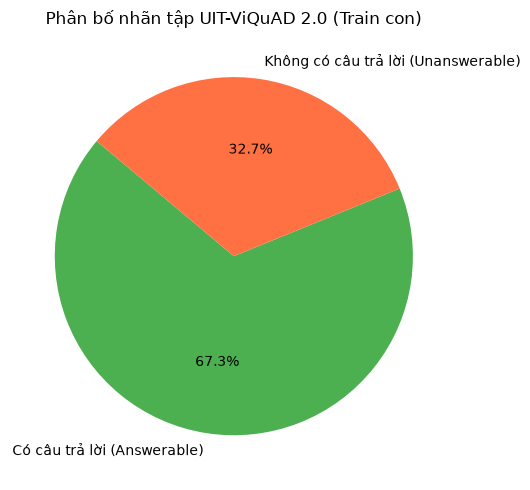

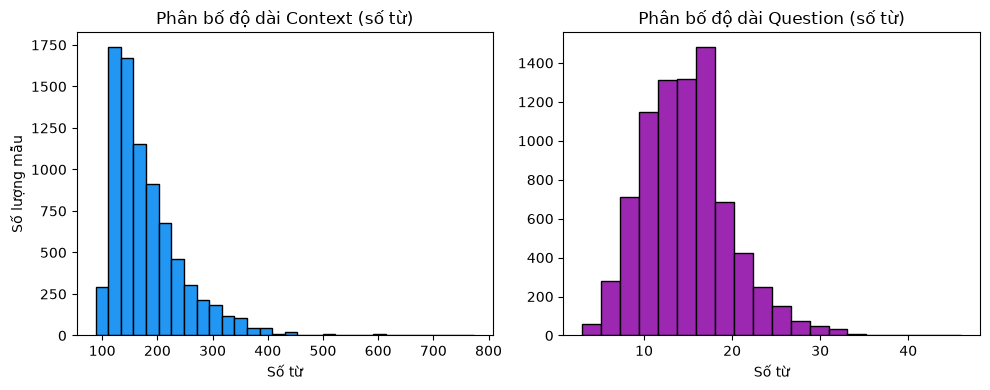

Đã lưu biểu đồ vào thư mục reports/images/!


In [10]:
os.makedirs("../reports/images", exist_ok=True)

# 1. Vẽ biểu đồ tròn phân bố tỷ lệ nhãn
plt.figure(figsize=(6, 5))
labels = ['Có câu trả lời (Answerable)', 'Không có câu trả lời (Unanswerable)']
sizes = [train_counts.get(False, 0), train_counts.get(True, 0)]
colors = ['#4CAF50', '#FF7043']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Phân bố nhãn tập UIT-ViQuAD 2.0 (Train con)")
plt.tight_layout()
plt.savefig("../reports/images/label_distribution.png", dpi=300)
plt.show()

# 2. Vẽ biểu đồ phân bố độ dài ngữ cảnh và câu hỏi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_train['context_word_count'], bins=30, color='#2196F3', edgecolor='black')
plt.title("Phân bố độ dài Context (số từ)")
plt.xlabel("Số từ")
plt.ylabel("Số lượng mẫu")

plt.subplot(1, 2, 2)
plt.hist(df_train['question_word_count'], bins=20, color='#9C27B0', edgecolor='black')
plt.title("Phân bố độ dài Question (số từ)")
plt.xlabel("Số từ")
plt.tight_layout()
plt.savefig("../reports/images/length_distribution.png", dpi=300)
plt.show()

print("Đã lưu biểu đồ vào thư mục reports/images/!")

Trích xuất 2 mẫu dữ liệu tiêu biểu cho Báo cáo

In [11]:
# Mẫu có câu trả lời (Answerable)
sample_ans = df_train[df_train['is_impossible'] == False].iloc[0]
print("Ví dụ 1: Câu hỏi có đáp án (Answerable)")
print("Context:", sample_ans['context'])
print("Question:", sample_ans['question'])
print("Answer Text:", sample_ans['answers']['text'][0])
print("Answer Start Index:", sample_ans['answers']['answer_start'][0])

# Mẫu không có câu trả lời (Unanswerable)
sample_unans = df_train[df_train['is_impossible'] == True].iloc[0]
print("\nVí dụ 2: Câu hỏi không có đáp án (Unanswerable)")
print("Context:", sample_unans['context'])
print("Question:", sample_unans['question'])
print("Answers:", sample_unans['answers']['text'])

Ví dụ 1: Câu hỏi có đáp án (Answerable)
Context: Truyền thuyết của người Êđê kể lại rằng: Một người thủ lĩnh (Krung) từ Ấn Độ tên là Kudaya (Đê) đến xứ sở của công chúa mẹ Xứ Sở tên là Nagar (Gar). Kudaya đã chinh phuc được xứ sở của Nagar sau đó kết hôn với công Chúa mẹ Xứ sở Nagar đựoc phong làm Krung. Con cháu hâu duệ của họ được gọi là Anak Kudaya Nagar sau này rút gọn âm lại thành Anak Đê-Gar có nghĩa là con cháu của thủ lĩnh Ấn Độ Kudaya(Đê) với Công Chúa xứ sở Nagar (Gar). Đây là truyền thuyết khá phổ biến ở cư dân bản địa Đông Nam Á để giải thích nguồn gốc cội nguồn.
Question: Con cháu của Kudaya và Nagar được gọi là gì?
Answer Text: Anak Kudaya Nagar
Answer Start Index: 293

Ví dụ 2: Câu hỏi không có đáp án (Unanswerable)
Context: Tại Nigiêria, ông tuyên bố rằng: "việc khai thác bất chấp đạo lý đối với người nghèo và kém hiểu biết là một tội ác chống lại Chúa"; tại Côlômbia ông cảnh cáo: "những người sống dư thừa và xa hoa vô độ thể hiện sự mù quáng về tinh thần". Người nghèo 